# Day 1: Convolution from Scratch

**COMP 395 — Deep Learning**

In this lab, you will:
1. Load and explore a grayscale image as a tensor
2. Implement the 2D convolution operation from scratch
3. Apply edge-detection kernels and visualize the results
4. Connect convolution to the CNN concepts from the LeCun et al. paper

**Paired work.** One person drives, one navigates. Switch roles at Part 3.

---

## Part 0: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# For inline plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'

## Part 1: Images as Tensors

### 1.1 Loading a grayscale image

We'll use a built-in test image. The "cameraman" image is a classic in image processing — it has clear edges (person, tripod, buildings) that make convolution results easy to interpret.

Shape: (512, 512)
Data type: float32
Value range: [0.0, 255.0]


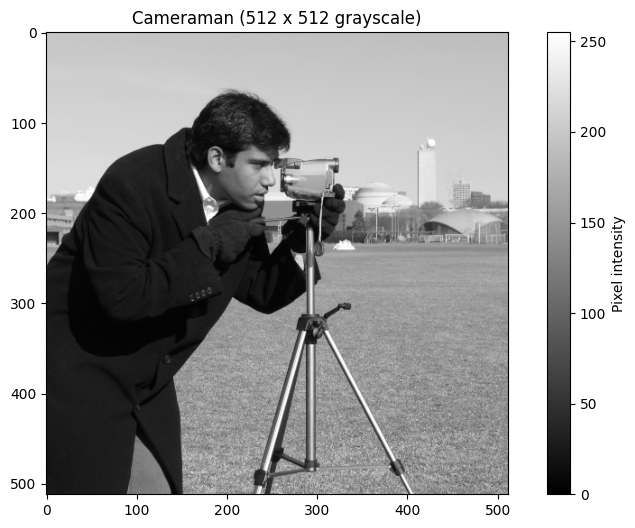

In [2]:
# Load the cameraman test image from scikit-image
from skimage import data

img_array = data.camera().astype(np.float32)  # shape: (512, 512), values 0-255

print(f"Shape: {img_array.shape}")
print(f"Data type: {img_array.dtype}")
print(f"Value range: [{img_array.min()}, {img_array.max()}]")

plt.imshow(img_array, cmap='gray')
plt.title("Cameraman (512 x 512 grayscale)")
plt.colorbar(label="Pixel intensity")
plt.show()

### 1.2 Zooming in: what the numbers look like

An image is just a matrix of numbers. Let's look at a small patch to see this concretely.

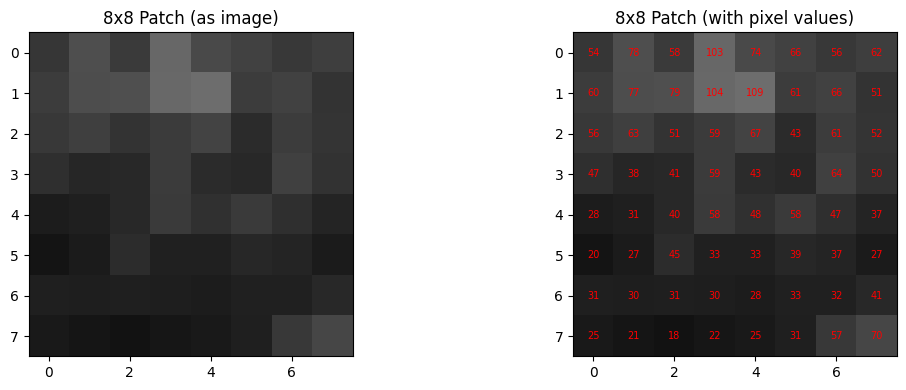

The raw numbers:
[[ 54  78  58 103  74  66  56  62]
 [ 60  77  79 104 109  61  66  51]
 [ 56  63  51  59  67  43  61  52]
 [ 47  38  41  59  43  40  64  50]
 [ 28  31  40  58  48  58  47  37]
 [ 20  27  45  33  33  39  37  27]
 [ 31  30  31  30  28  33  32  41]
 [ 25  21  18  22  25  31  57  70]]


In [3]:
# Extract a small 8x8 patch from an interesting region (around an edge)
patch = img_array[100:108, 200:208]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Show the patch as an image
axes[0].imshow(patch, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("8x8 Patch (as image)")

# Show the actual numbers
axes[1].imshow(patch, cmap='gray', vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, f"{int(patch[i,j])}", ha='center', va='center',
                     fontsize=7, color='red' if patch[i,j] < 128 else 'yellow')
axes[1].set_title("8x8 Patch (with pixel values)")

plt.tight_layout()
plt.show()

print("The raw numbers:")
print(patch.astype(int))

### 1.3 Converting to a PyTorch tensor

For now we'll work in NumPy (the loops are clearer), but let's confirm we know how to move between NumPy and PyTorch.

In [4]:
img_tensor = torch.from_numpy(img_array)
print(f"PyTorch tensor shape: {img_tensor.shape}")
print(f"PyTorch dtype: {img_tensor.dtype}")

# And back:
back_to_numpy = img_tensor.numpy()
print(f"Round-trip check (arrays equal): {np.allclose(img_array, back_to_numpy)}")

PyTorch tensor shape: torch.Size([512, 512])
PyTorch dtype: torch.float32
Round-trip check (arrays equal): True


## Part 2: Understanding Convolution

### The idea

A **kernel** (or **filter**) is a small matrix (usually 3×3). We slide it across the image, and at each position we:
1. Overlay the kernel on the image patch
2. Multiply element-wise
3. Sum all the products
4. Write the result to the output

Mathematically, for a kernel $K$ of size $k \times k$:

$$\text{Output}(i, j) = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} I(i+m, j+n) \cdot K(m, n)$$

The output image has shape $(H - k + 1, W - k + 1)$ — it shrinks slightly because the kernel can't extend past the image boundary (we're not using padding today).

### 2.1 A concrete example by hand

Before coding, let's do one convolution step by hand to make sure we understand.

In [5]:
# A tiny 5x5 "image"
tiny_image = np.array([
    [10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10],
    [200, 200, 200, 200, 200],
    [200, 200, 200, 200, 200]
], dtype=np.float32)

# A horizontal edge detection kernel
h_edge_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

# Let's manually compute the output at position (1, 1):
patch = tiny_image[1:4, 1:4]  # rows 1-3, cols 1-3
print("Image patch at (1,1):")
print(patch.astype(int))
print()
print("Kernel:")
print(h_edge_kernel.astype(int))
print()
print("Element-wise product:")
print((patch * h_edge_kernel).astype(int))
print()
result = np.sum(patch * h_edge_kernel)
print(f"Sum (convolution output at position 1,1): {result}")
print()
print("This large positive value means: there IS a horizontal edge here!")
print("(Pixel values jump from 10 to 200 going top to bottom)")

Image patch at (1,1):
[[ 10  10  10]
 [ 10  10  10]
 [200 200 200]]

Kernel:
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]

Element-wise product:
[[-10 -10 -10]
 [  0   0   0]
 [200 200 200]]

Sum (convolution output at position 1,1): 570.0

This large positive value means: there IS a horizontal edge here!
(Pixel values jump from 10 to 200 going top to bottom)


### ✏️ Think–Pair–Share

Before you start coding, discuss with your partner:

1. What would the output be at position (0, 0)? (Hint: the patch is rows 0-2, cols 0-2 — all 10s.)
2. What about at position (0, 1)? Same values?
3. Why does the kernel `[-1, -1, -1; 0, 0, 0; 1, 1, 1]` detect *horizontal* edges specifically?

---

## Part 3: Implement Convolution from Scratch

**🔄 Switch driver/navigator here.**

### 3.1 Your task

Complete the `convolve2d` function below. You need to:
1. Compute the output dimensions
2. Write four nested loops: two outer loops to slide the kernel across the image, two inner loops to compute the element-wise multiply-and-sum at each position
3. Return the output image

**Do not use `scipy.signal.convolve2d` or any other library convolution.** The point is to see exactly what's happening.

In [ ]:
def convolve2d(image, kernel):
    """
    Apply a 2D convolution of `kernel` over `image`.

    Parameters
    ----------
    image : np.ndarray, shape (H, W)
        Grayscale image as a 2D array.
    kernel : np.ndarray, shape (k, k)
        Square convolution kernel.

    Returns
    -------
    output : np.ndarray, shape (H - k + 1, W - k + 1)
        The convolution result.
    """
    H, W = image.shape
    k = kernel.shape[0]  # kernel is k x k

    out_h = H - k+1  # FILL IN
    out_w = W- k+1  # FILL IN

    # Initialize output array with zeros
    output = np.zeros((out_h, out_w), dtype=np.float32)

    # TODO: Four nested loops
    # Outer two loops: slide kernel across the image (positions i, j)
    # Inner two loops: element-wise multiply and sum (offsets m, n)
    for i in range(out_h):
        for j in range(out_w):
            # TODO: Compute the convolution at position (i, j)
            # Hint: extract the patch image[i:i+k, j:j+k], multiply by kernel, sum
            patch = image[i:i+k, j:j+k]
            convoluted = patch*kernel
            output[i, j] = convoluted.sum()

    return output


### 3.2 Test with the identity kernel

The identity kernel should return (approximately) the same image, just slightly smaller. This is your sanity check.

Input shape: (512, 512)
Output shape: (510, 510)


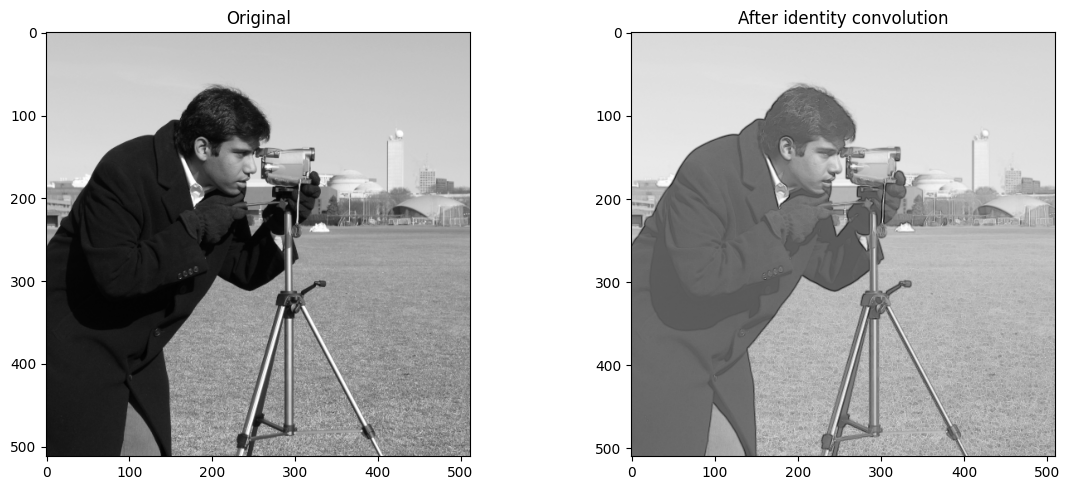

Max difference from expected: 1020.0
(Should be 0.0 if your implementation is correct)


In [31]:
# Identity kernel: copies the center pixel
identity_kernel = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Test on the cameraman image
sobel_y_output = convolve2d(img_array, identity_kernel)
sobel_x_output = convolve2d(img_array, sobel_x)
edge_magnitude = np.sqrt(sobel_x_output**2 + sobel_y_output**2)
shrunk_img = img_array[1:511, 1:511]
identity_output = shrunk_img*5-(edge_magnitude)


print(f"Input shape: {img_array.shape}")
print(f"Output shape: {identity_output.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(identity_output, cmap='gray')
axes[1].set_title("After identity convolution")
plt.tight_layout()
plt.show()

# Numerical check: the output should match the interior of the input
interior = img_array[1:-1, 1:-1]
print(f"Max difference from expected: {np.max(np.abs(identity_output - interior))}")
print("(Should be 0.0 if your implementation is correct)")

### 3.3 Test on the tiny image

Let's verify against our hand calculation from Part 2.

In [15]:
# Test on the tiny image from earlier
tiny_output = convolve2d(tiny_image, h_edge_kernel)
print("Tiny image convolution output:")
print(tiny_output.astype(int))
print()
print("Position (1,1) should be 570 (from our hand calculation)")
print(f"Your result at (1,1): {tiny_output[1,1]}")

Tiny image convolution output:
[[  0   0   0]
 [570 570 570]
 [570 570 570]]

Position (1,1) should be 570 (from our hand calculation)
Your result at (1,1): 570.0


## Part 4: Edge Detection on a Real Image

Now let's apply meaningful kernels to the cameraman image and see what convolution *actually detects*.

### ✏️ Prediction (write your answer before running the code)

Look at the cameraman image above. Before applying the kernels:
- **Horizontal edge kernel**: which parts of the image do you expect will "light up"?
- **Vertical edge kernel**: which parts?

*Your prediction:*

(Write here)

---

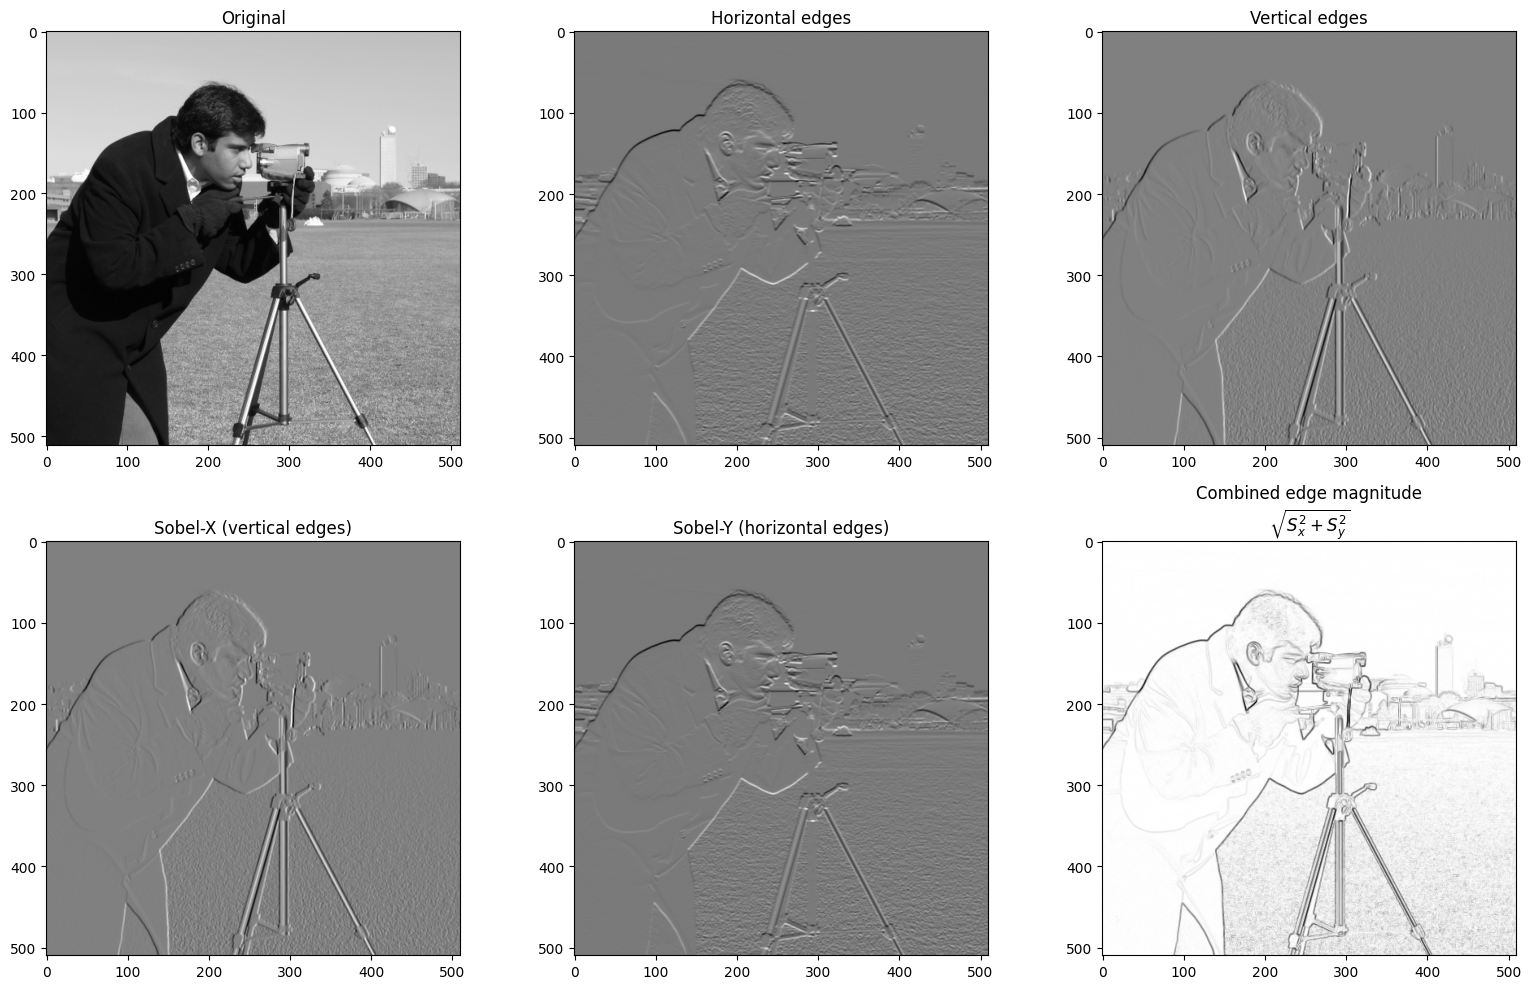

In [22]:
# Define the kernels
kernels = {
    "Horizontal edges": np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=np.float32),

    "Vertical edges": np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32),

    "Sobel-X (vertical edges)": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32),

    "Sobel-Y (horizontal edges)": np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float32),
}

# Apply each kernel and visualize
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Original image
axes[0, 0].imshow(img_array, cmap='gray')
axes[0, 0].set_title("Original", fontsize=12)

for idx, (name, kernel) in enumerate(kernels.items()):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    output = convolve2d(img_array, kernel)
    axes[row, col].imshow(output, cmap='gray')
    axes[row, col].set_title(name, fontsize=12)

# Combined edge magnitude (Sobel)
sobel_x = convolve2d(img_array, kernels["Sobel-X (vertical edges)"])
sobel_y = convolve2d(img_array, kernels["Sobel-Y (horizontal edges)"])
edge_magnitude = -np.sqrt(sobel_x**2 + sobel_y**2)

axes[1, 2].imshow(edge_magnitude, cmap='gray')
axes[1, 2].set_title("Combined edge magnitude\n$\sqrt{S_x^2 + S_y^2}$", fontsize=12)

plt.tight_layout()
plt.show()

### ✏️ Think–Pair–Share

1. **Check your predictions:** Did the horizontal and vertical edge kernels highlight what you expected? What surprised you?

2. **Sobel vs. simple edge kernels:** Look carefully at the Sobel outputs vs. the simple edge outputs. The Sobel operators have a `2` in the center row/column. What effect does this have on the output? (Hint: think about noise.)

3. **Combined magnitude:** The last panel computes $\sqrt{S_x^2 + S_y^2}$. Why does combining both directions give us the "full" edges?

4. **Connection to CNNs:** In a CNN, the kernel values are *learned* by backpropagation. What would it mean for a network to "learn" a Sobel-like filter in its first layer?

---

## Part 5: Experimentation

Try some more kernels to build intuition. For each one, predict what it will do *before* running the code.

### 5.1 Blur kernel

This kernel averages a pixel with its neighbors.

In [ ]:
# Box blur: average of the 3x3 neighborhood
blur_kernel = np.ones((3, 3), dtype=np.float32) / 9.0

print("Blur kernel:")
print(blur_kernel.round(3))

blur_output = convolve2d(img_array, blur_kernel)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(blur_output, cmap='gray')
axes[1].set_title("After blur (3x3 box filter)")
plt.tight_layout()
plt.show()

### 5.2 Sharpen kernel

In [ ]:
# Sharpen: emphasize the center pixel, subtract neighbors
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

sharpen_output = convolve2d(img_array, sharpen_kernel)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(sharpen_output, cmap='gray')
axes[1].set_title("After sharpen")
plt.tight_layout()
plt.show()

### 5.3 Your turn: design a kernel

Create your own 3×3 kernel. Some ideas:
- A diagonal edge detector
- A stronger blur (what if you average over 5×5?)
- An emboss effect (try `[[-2,-1,0],[-1,1,1],[0,1,2]]`)

Predict what it will do, then test it.

In [ ]:
# TODO: Design your own kernel
my_kernel = np.array([
    # FILL IN your 3x3 kernel
], dtype=np.float32)

my_output = convolve2d(img_array, my_kernel)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(my_output, cmap='gray')
axes[1].set_title("My custom kernel")
plt.tight_layout()
plt.show()

## Part 6: Reflection & Exit Ticket

### ✏️ Answer these in your own words (graded for completeness, not correctness):

**1.** In one or two sentences, what does the convolution operation do to an image?

*Your answer:*

**2.** Our `convolve2d` function has four nested loops. In Big-O notation, what is the time complexity in terms of image dimensions ($H$, $W$) and kernel size ($k$)? Why is this relevant for real CNN training?

*Your answer:*

**3.** In the LeCun paper, the authors describe how early CNN layers learn edge-like features and deeper layers learn more complex shapes. Based on today's lab, why do you think edges are a natural "first thing" to detect?

*Your answer:*

**4.** What is one thing that clicked for you today, and one thing you're still unsure about?

*Your answer:*

---

**Next class:** We'll extend convolution to color (RGB) images, introduce pooling, and see how PyTorch's `nn.Conv2d` does everything we did today — but fast and differentiable. This will set us up to build a full CNN for MNIST digit classification.